# 01 — Data Understanding & EDA
**Prague Stay Management**

**Cíl:** Pochopit strukturu, kvalitu a vlastnosti zdrojových dat. Identifikovat problémy, které je třeba řešit v následující fázi přípravy dat.

**Datasety:**
- `listings_csv.gz` — Airbnb nabídky v Praze (Inside Airbnb, reálná data)
- `calendar_csv.gz` — dostupnost bytů po dnech (Inside Airbnb, reálná data)
- `metro_stations.csv` — stanice metra Praha (AI-generováno, syntetická data)

---

## 0. Importy a nastavení

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
import gzip
import shutil
import os
import warnings
warnings.filterwarnings('ignore')


sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

RAW = '../data/raw/'
print('Importy OK')

Importy OK


---
## 1. Načtení dat

In [2]:
RAW = '../data/raw/'

# Rozbalení listings_csv.gz → listings.csv
with gzip.open(RAW + 'listings.csv.gz', 'rb') as f_in:
    with open(RAW + 'listings.csv', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

# Rozbalení calendar_csv.gz → calendar.csv
with gzip.open(RAW + 'calendar.csv.gz', 'rb') as f_in:
    with open(RAW + 'calendar.csv', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

print(f"listings.csv:  {os.path.getsize(RAW + 'listings.csv') / 1024 / 1024:.1f} MB")
print(f"calendar.csv:  {os.path.getsize(RAW + 'calendar.csv') / 1024 / 1024:.1f} MB")

listings = pd.read_csv(RAW + 'listings.csv')
calendar = pd.read_csv(RAW + 'calendar.csv')
metro    = pd.read_csv(RAW + 'metro_stations.csv')

listings.csv:  24.2 MB
calendar.csv:  139.4 MB


---
## 2. Listings
### 2.1 Prvních a posledních 5 řádků

In [3]:
print('=== PRVNÍCH 5 ŘÁDKŮ ===')
listings.head()

=== PRVNÍCH 5 ŘÁDKŮ ===


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,23163,https://www.airbnb.com/rooms/23163,20250923203415,2025-09-24,previous scrape,Residence Karolina - KAROL12,"Unique and elegant apartment rental in Prague,...",NaN,https://a0.muscache.com/pictures/01bbe32c-3f13...,5282,...,4.97,4.93,4.86,NaN,t,75,74,0,0,0.17
1,23169,https://www.airbnb.com/rooms/23169,20250923203415,2025-09-24,city scrape,Residence Masna - Masna302,Masna studio offers a lot of space and privacy...,NaN,https://a0.muscache.com/pictures/b450cf2a-8561...,5282,...,4.86,4.97,4.69,NaN,t,75,74,0,0,0.66
2,26755,https://www.airbnb.com/rooms/26755,20250923203415,2025-09-24,city scrape,Central Prague Old Town Top Floor,Big and beautiful new attic apartment in the v...,This apartment offers a fantastic location. Yo...,https://a0.muscache.com/pictures/miso/Hosting-...,113902,...,4.96,4.94,4.90,NaN,f,3,3,0,0,3.49
3,30762,https://www.airbnb.com/rooms/30762,20250923203415,2025-09-24,city scrape,Residence Rybna - Rybna23,"We offer a modern, comfortable, serviced apart...",NaN,https://a0.muscache.com/pictures/dfbb2fc2-91a0...,5282,...,4.53,4.88,4.41,NaN,t,75,74,0,0,0.10
4,42514,https://www.airbnb.com/rooms/42514,20250923203415,2025-09-24,city scrape,"""NEWLY FURNISHED"" 1BR near Pachtuv Palace,Old ...",*NEWLY* Furnished 1-bedroom apartment on the f...,NaN,https://a0.muscache.com/pictures/7f66bc43-25c7...,185641,...,4.84,4.90,4.79,NaN,f,1,1,0,0,1.81


In [4]:
print('=== POSLEDNÍCH 5 ŘÁDKŮ ===')
listings.tail()

=== POSLEDNÍCH 5 ŘÁDKŮ ===


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
10829,1515809052516808785,https://www.airbnb.com/rooms/1515809052516808785,20250923203415,2025-09-23,city scrape,"Cozy flat w/ Balcony&Parking, near Metro & Centre",Modern 1BR apartment in Prague 5 with balcony ...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,176252442,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
10830,1515820376391468787,https://www.airbnb.com/rooms/1515820376391468787,20250923203415,2025-09-24,city scrape,Peaceful Apartment next to Jubilee Synagogue,"Beautiful apartment in central Prague, just 1 ...",Strategically positioned between Prague's ench...,https://a0.muscache.com/pictures/prohost-api/H...,227945,...,NaN,NaN,NaN,NaN,t,95,95,0,0,NaN
10831,1515865729897302482,https://www.airbnb.com/rooms/1515865729897302482,20250923203415,2025-09-24,city scrape,Apartment Spalená,This home has a great location located very cl...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,314317287,...,NaN,NaN,NaN,NaN,f,2,1,1,0,NaN
10832,1515888570117465214,https://www.airbnb.com/rooms/1515888570117465214,20250923203415,2025-09-24,city scrape,Fresh Apartment next to Prague City Center at ...,🛋️ 47 m² of comfort – ideal for families or sm...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,523424457,...,NaN,NaN,NaN,NaN,t,39,39,0,0,NaN
10833,1516082767638714383,https://www.airbnb.com/rooms/1516082767638714383,20250923203415,2025-09-24,city scrape,Garden Residence Terrace Apartment,Our apartment is located in a modern residenti...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,255954966,...,NaN,NaN,NaN,NaN,t,2,2,0,0,NaN


### 2.2 Datové typy a přehled sloupců

In [5]:
print("=== LISTINGS INFO ===")
listings.info()

=== LISTINGS INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 10834 entries, 0 to 10833
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            10834 non-null  int64  
 1   listing_url                                   10834 non-null  str    
 2   scrape_id                                     10834 non-null  int64  
 3   last_scraped                                  10834 non-null  str    
 4   source                                        10834 non-null  str    
 5   name                                          10834 non-null  str    
 6   description                                   10614 non-null  str    
 7   neighborhood_overview                         4458 non-null   str    
 8   picture_url                                   10833 non-null  str    
 9   host_id                                       1083

### 2.3 Chybějící hodnoty

In [6]:
null_stats = pd.DataFrame({
    'null_count': listings.isnull().sum(),
    'null_pct':   (listings.isnull().mean() * 100).round(1)
})
null_stats = null_stats[null_stats['null_count'] > 0].sort_values('null_pct', ascending=False)

print(f'Sloupce BEZ chybějících hodnot: {listings.shape[1] - len(null_stats)} / {listings.shape[1]}')
print(f'Sloupce S chybějícími hodnotami: {len(null_stats)} / {listings.shape[1]}')
print()
print(null_stats.to_string())

Sloupce BEZ chybějících hodnot: 35 / 79
Sloupce S chybějícími hodnotami: 44 / 79

                              null_count  null_pct
license                            10834     100.0
neighbourhood_group_cleansed       10834     100.0
calendar_updated                   10834     100.0
neighborhood_overview               6376      58.9
neighbourhood                       6376      58.9
host_about                          4365      40.3
host_location                       2568      23.7
estimated_revenue_l365d             1336      12.3
price                               1336      12.3
beds                                1277      11.8
bathrooms                           1261      11.6
review_scores_accuracy               952       8.8
first_review                         951       8.8
last_review                          951       8.8
review_scores_rating                 951       8.8
reviews_per_month                    951       8.8
review_scores_cleanliness            951       8.8


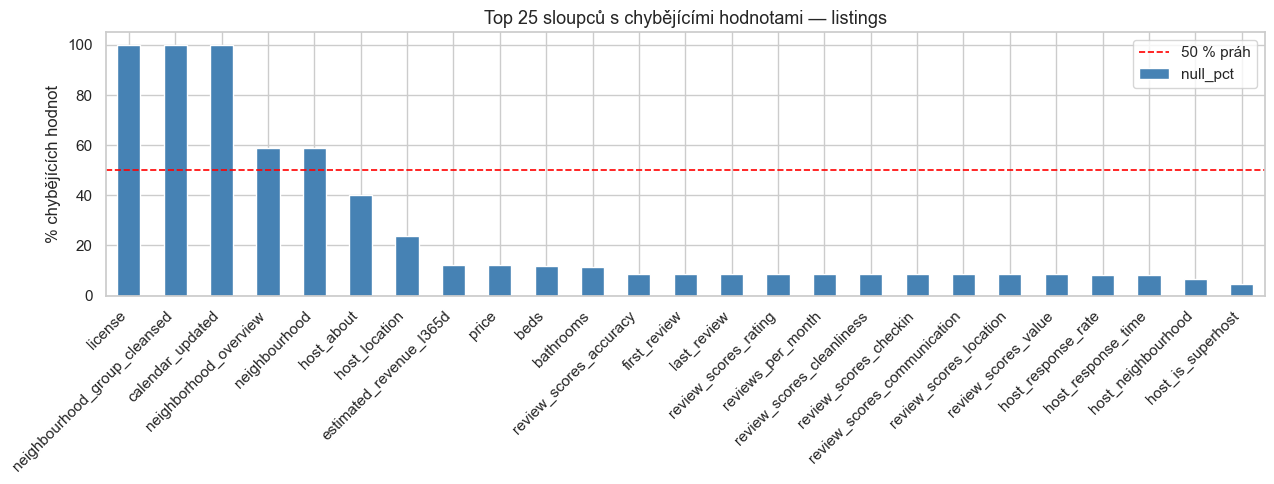

Sloupce s > 50 % NaN: ['license', 'neighbourhood_group_cleansed', 'calendar_updated', 'neighborhood_overview', 'neighbourhood']


In [7]:
# Vizualizace top 25 sloupců s NaN
fig, ax = plt.subplots(figsize=(13, 5))
null_stats.head(25)['null_pct'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axhline(y=50, color='red', linestyle='--', linewidth=1.2, label='50 % práh')
ax.set_title('Top 25 sloupců s chybějícími hodnotami — listings')
ax.set_ylabel('% chybějících hodnot')
ax.set_xlabel('')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

high_null = null_stats[null_stats['null_pct'] > 50]
print(f'Sloupce s > 50 % NaN: {list(high_null.index)}')

### 2.4 Duplikáty

In [8]:
dup_rows = listings.duplicated().sum()
dup_ids  = listings['id'].duplicated().sum()

print(f'Duplicitní řádky (celý řádek):  {dup_rows}')
print(f'Duplicitní ID nabídky:           {dup_ids}')

if dup_rows == 0 and dup_ids == 0:
    print('Žádné duplikáty nenalezeny.')
else:
    print('Duplikáty nalezeny — řešit v 02_data_preparation.')

Duplicitní řádky (celý řádek):  0
Duplicitní ID nabídky:           0
Žádné duplikáty nenalezeny.


### 2.5 Základní statistiky klíčových sloupců

In [9]:
# Pomocná čistá cena pro statistiky
listings['price_czk'] = (
    listings['price']
    .str.replace(r'[\$,]', '', regex=True)
    .astype(float)
)

kpi_cols = [
    'price_czk', 'accommodates', 'bedrooms', 'beds',
    'availability_365', 'estimated_occupancy_l365d',
    'estimated_revenue_l365d', 'number_of_reviews', 'review_scores_rating'
]

listings[kpi_cols].describe().round(2)

,price_czk,accommodates,bedrooms,beds,availability_365,estimated_occupancy_l365d,estimated_revenue_l365d,number_of_reviews,review_scores_rating
count,9498.00,10834.00,10526.0,9557.00,10834.00,10834.00,9498.00,10834.00,9883.00
mean,4010.18,4.06,1.4,2.51,179.66,103.22,283748.55,77.88,4.74
std,17025.40,2.55,1.0,2.22,124.15,99.58,435867.66,117.89,0.35
min,223.00,1.00,0.0,0.00,0.00,0.00,0.00,0.00,1.00
25%,1536.00,2.00,1.0,1.00,61.00,6.00,34087.50,6.00,4.67
50%,2152.00,4.00,1.0,2.00,172.00,66.00,173653.50,29.00,4.83
75%,3183.75,5.00,2.0,3.00,303.00,210.00,401382.00,97.00,4.94
max,632000.00,16.00,34.0,32.00,365.00,255.00,15125526.00,1943.00,5.00


### 2.6 Kategorické sloupce

In [10]:
cat_cols = ['room_type', 'neighbourhood_cleansed', 'host_response_time', 'instant_bookable']

for col in cat_cols:
    print(f'--- {col} ---')
    print(listings[col].value_counts().to_string())
    print()

--- room_type ---
room_type
Entire home/apt    8973
Private room       1680
Hotel room           95
Shared room          86

--- neighbourhood_cleansed ---
neighbourhood_cleansed
Praha 1            3831
Praha 2            2046
Praha 3            1209
Praha 5             930
Praha 8             601
Praha 7             511
Praha 10            376
Praha 6             363
Praha 4             355
Praha 9             124
Praha 13             72
Praha 11             47
Praha 14             35
Praha 12             31
Praha 15             30
Libuš                29
Velká Chuchle        27
Zbraslav             15
Praha 18             14
Kunratice            13
Zličín               12
Praha 17             10
Praha 22             10
Troja                10
Dolní Chabry         10
Šeberov               9
Dolní Počernice       8
Praha 19              8
Petrovice             7
Praha 16              7
Řeporyje              7
Slivenec              7
Suchdol               7
Praha 21              6
Čakov

### 2.7 Detekce outlierů (IQR metoda)

In [11]:
def detect_outliers_iqr(series, label):
    s = series.dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = ((s < lower) | (s > upper)).sum()
    pct = outliers / len(s) * 100
    print(f'{label:<38} outlierů: {outliers:>5}  ({pct:.1f} %)   '
          f'normální rozsah: [{lower:,.0f} — {upper:,.0f}]')

print('Detekce outlierů (IQR × 1.5 pravidlo):')
print('-' * 95)
for col in ['price_czk', 'accommodates', 'estimated_revenue_l365d',
            'estimated_occupancy_l365d', 'number_of_reviews', 'availability_365']:
    detect_outliers_iqr(listings[col], col)

Detekce outlierů (IQR × 1.5 pravidlo):
-----------------------------------------------------------------------------------------------
price_czk                              outlierů:   722  (7.6 %)   normální rozsah: [-936 — 5,655]
accommodates                           outlierů:   494  (4.6 %)   normální rozsah: [-2 — 10]
estimated_revenue_l365d                outlierů:   388  (4.1 %)   normální rozsah: [-516,854 — 952,324]
estimated_occupancy_l365d              outlierů:     0  (0.0 %)   normální rozsah: [-300 — 516]
number_of_reviews                      outlierů:  1022  (9.4 %)   normální rozsah: [-130 — 234]
availability_365                       outlierů:     0  (0.0 %)   normální rozsah: [-302 — 666]


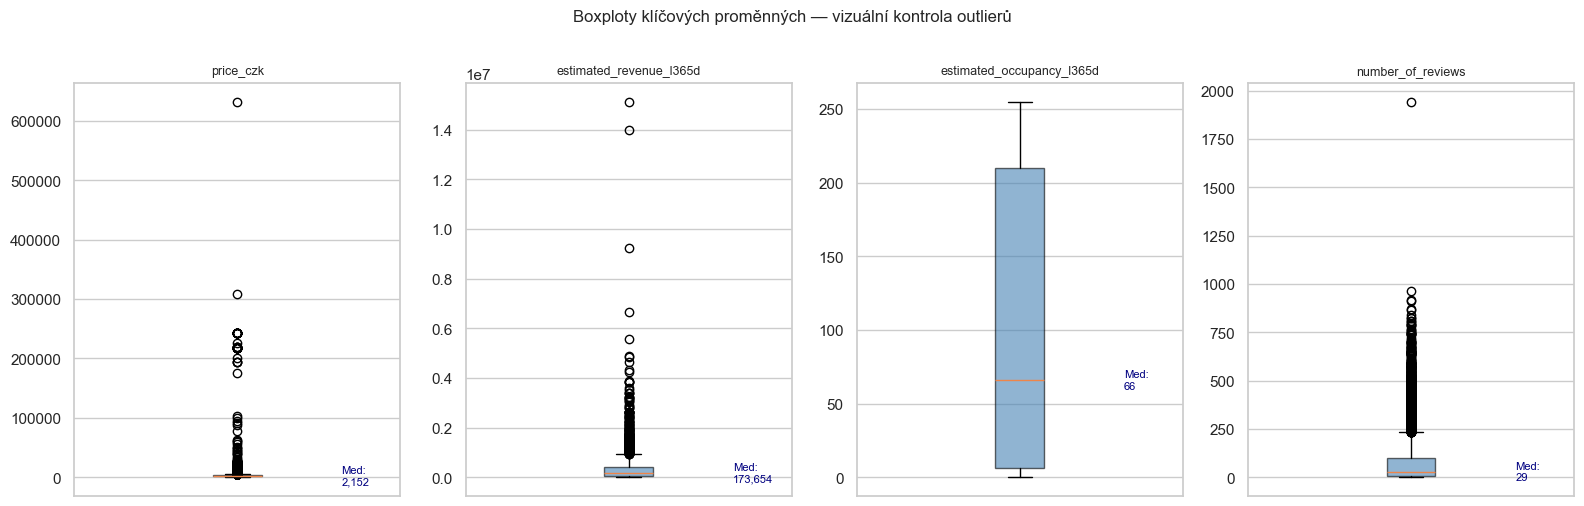

In [12]:
# Boxploty pro vizuální kontrolu outlierů
outlier_cols = ['price_czk', 'estimated_revenue_l365d',
                'estimated_occupancy_l365d', 'number_of_reviews']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, outlier_cols):
    data = listings[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col, fontsize=9)
    ax.set_xticks([])
    ax.text(1.32, data.median(),
            f'Med:\n{data.median():,.0f}', fontsize=8, va='center', color='navy')

plt.suptitle('Boxploty klíčových proměnných — vizuální kontrola outlierů', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### 2.8 Distribuce klíčových proměnných

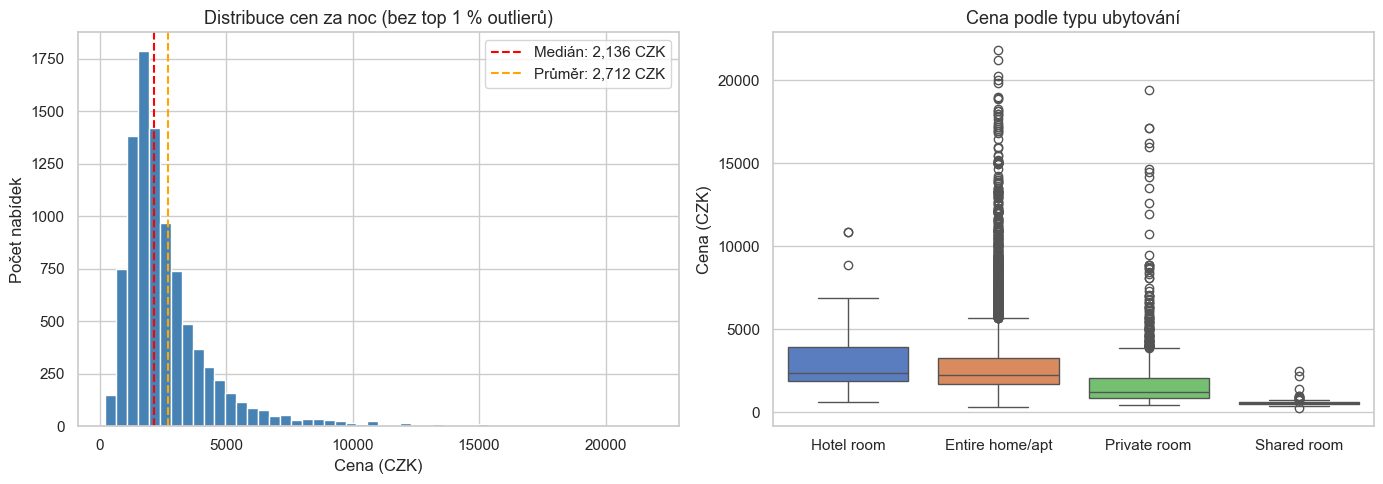

In [13]:
# Cena za noc
p99 = listings['price_czk'].quantile(0.99)
price_trimmed = listings.loc[listings['price_czk'] <= p99, 'price_czk']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(price_trimmed.dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(price_trimmed.median(), color='red', linestyle='--',
                label=f'Medián: {price_trimmed.median():,.0f} CZK')
axes[0].axvline(price_trimmed.mean(), color='orange', linestyle='--',
                label=f'Průměr: {price_trimmed.mean():,.0f} CZK')
axes[0].set_title('Distribuce cen za noc (bez top 1 % outlierů)')
axes[0].set_xlabel('Cena (CZK)')
axes[0].set_ylabel('Počet nabídek')
axes[0].legend()

room_price = listings.loc[listings['price_czk'] <= p99, ['room_type', 'price_czk']]
order = room_price.groupby('room_type')['price_czk'].median().sort_values(ascending=False).index
sns.boxplot(data=room_price, x='room_type', y='price_czk', order=order, ax=axes[1], palette='muted')
axes[1].set_title('Cena podle typu ubytování')
axes[1].set_xlabel('')
axes[1].set_ylabel('Cena (CZK)')

plt.tight_layout()
plt.show()

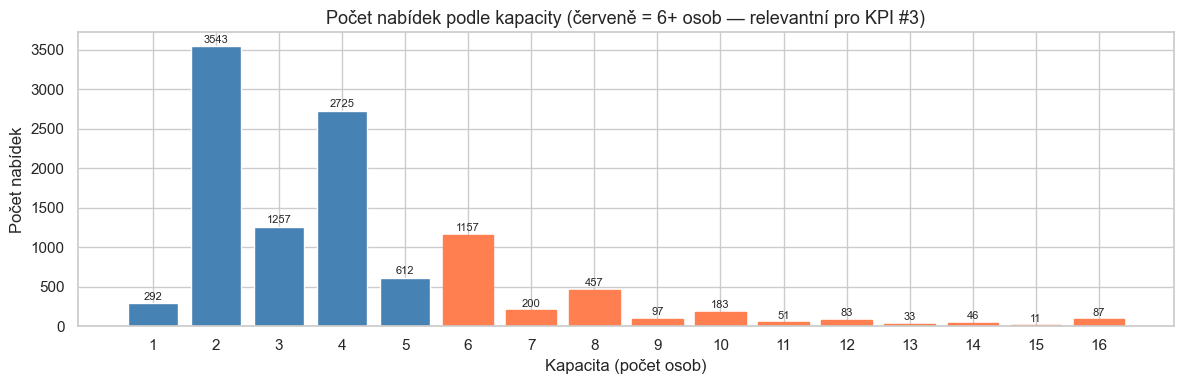

Velké byty (6+ osob): 2,405 (22.2 % portfolia)


In [14]:
# Kapacita bytů — accommodates (základ pro KPI #3)
acc_counts = listings['accommodates'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(acc_counts.index, acc_counts.values, color='steelblue', edgecolor='white')

for bar, idx in zip(bars, acc_counts.index):
    if idx >= 6:
        bar.set_color('coral')
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 20, str(int(h)),
            ha='center', va='bottom', fontsize=8)

ax.set_title('Počet nabídek podle kapacity (červeně = 6+ osob — relevantní pro KPI #3)')
ax.set_xlabel('Kapacita (počet osob)')
ax.set_ylabel('Počet nabídek')
ax.set_xticks(acc_counts.index)
plt.tight_layout()
plt.show()

large = listings[listings['accommodates'] >= 6]
print(f'Velké byty (6+ osob): {len(large):,} ({len(large)/len(listings)*100:.1f} % portfolia)')

### 2.9 Korelační analýza

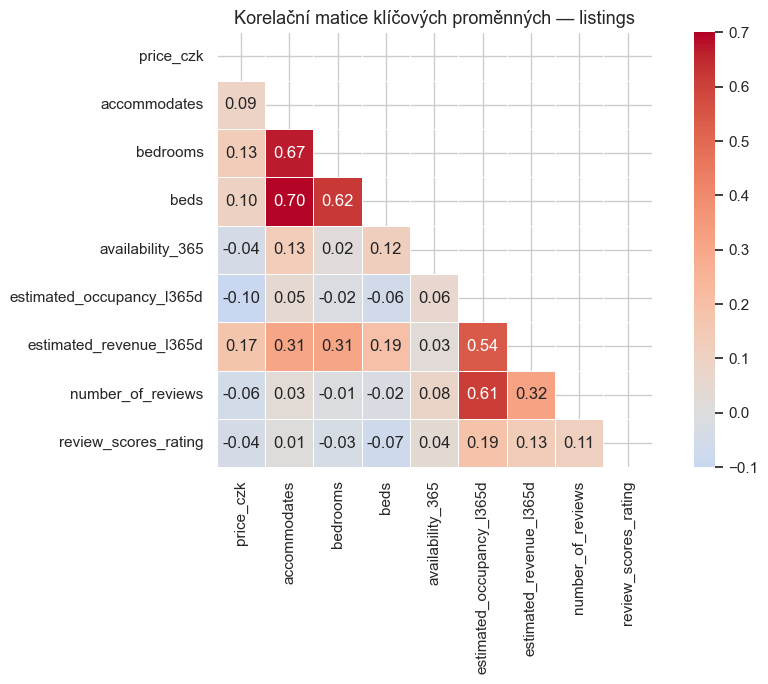

In [15]:
corr_cols = [
    'price_czk', 'accommodates', 'bedrooms', 'beds',
    'availability_365', 'estimated_occupancy_l365d',
    'estimated_revenue_l365d', 'number_of_reviews', 'review_scores_rating'
]

corr_matrix = listings[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, square=True, linewidths=0.5, ax=ax
)
ax.set_title('Korelační matice klíčových proměnných — listings')
plt.tight_layout()
plt.show()

### 2.10 Anomálie

In [16]:
print("=== LOGICKÉ ANOMÁLIE — listings ===")
print(f"price_czk < 0:                    {(listings['price_czk'] < 0).sum()}")
print(f"price_czk == 0:                   {(listings['price_czk'] == 0).sum()}")
print(f"accommodates == 0:                {(listings['accommodates'] == 0).sum()}")
print(f"availability_365 > 365:           {(listings['availability_365'] > 365).sum()}")
print(f"availability_365 < 0:             {(listings['availability_365'] < 0).sum()}")
print(f"revenue > 0 ale occupancy == 0:   {((listings['estimated_revenue_l365d'] > 0) & (listings['estimated_occupancy_l365d'] == 0)).sum()}")
print(f"occupancy > 365:                  {(listings['estimated_occupancy_l365d'] > 365).sum()}")

=== LOGICKÉ ANOMÁLIE — listings ===
price_czk < 0:                    0
price_czk == 0:                   0
accommodates == 0:                0
availability_365 > 365:           0
availability_365 < 0:             0
revenue > 0 ale occupancy == 0:   0
occupancy > 365:                  0


---
## 3. Calendar
### 3.1 Prvních a posledních 5 řádků

In [17]:
print('=== PRVNÍCH 5 ŘÁDKŮ ===')
calendar.head()

=== PRVNÍCH 5 ŘÁDKŮ ===


,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,23163,2025-09-24,f,NaN,NaN,1,731
1,23163,2025-09-25,f,NaN,NaN,1,731
2,23163,2025-09-26,f,NaN,NaN,1,731
3,23163,2025-09-27,f,NaN,NaN,1,731
4,23163,2025-09-28,f,NaN,NaN,1,731


In [18]:
print('=== POSLEDNÍCH 5 ŘÁDKŮ ===')
calendar.tail()

=== POSLEDNÍCH 5 ŘÁDKŮ ===


,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
3954406,15128376,2026-09-19,f,NaN,NaN,5,1125
3954407,15128376,2026-09-20,f,NaN,NaN,5,1125
3954408,15128376,2026-09-21,f,NaN,NaN,5,1125
3954409,15128376,2026-09-22,f,NaN,NaN,5,1125
3954410,15128376,2026-09-23,f,NaN,NaN,5,1125


### 3.2 Struktura, chybějící hodnoty a duplikáty

In [19]:
print(f'Shape: {calendar.shape[0]:,} řádků × {calendar.shape[1]} sloupců')
print()
print('Datové typy:')
print(calendar.dtypes.to_string())
print()
print('Chybějící hodnoty (%):')
print((calendar.isnull().mean() * 100).round(1).to_string())

Shape: 3,954,411 řádků × 7 sloupců

Datové typy:
listing_id          int64
date                  str
available             str
price             float64
adjusted_price    float64
minimum_nights      int64
maximum_nights      int64

Chybějící hodnoty (%):
listing_id          0.0
date                0.0
available           0.0
price             100.0
adjusted_price    100.0
minimum_nights      0.0
maximum_nights      0.0


In [20]:
dup_cal     = calendar.duplicated().sum()
dup_cal_key = calendar.duplicated(subset=['listing_id', 'date']).sum()
print(f'Duplicitní řádky (celý řádek):        {dup_cal}')
print(f'Duplicitní kombinace listing_id+date: {dup_cal_key}')

calendar['date'] = pd.to_datetime(calendar['date'])
print(f'\nRozsah dat:              {calendar["date"].min().date()} → {calendar["date"].max().date()}')
print(f'Unikátní nabídky:        {calendar["listing_id"].nunique():,}')
print(f'Hodnoty available:       {calendar["available"].value_counts().to_dict()}')

Duplicitní řádky (celý řádek):        0
Duplicitní kombinace listing_id+date: 0

Rozsah dat:              2025-09-23 → 2026-09-23
Unikátní nabídky:        10,834
Hodnoty available:       {'f': 2006447, 't': 1947964}


### 3.3 Sezónnost — obsazenost po měsících (základ pro KPI #2)

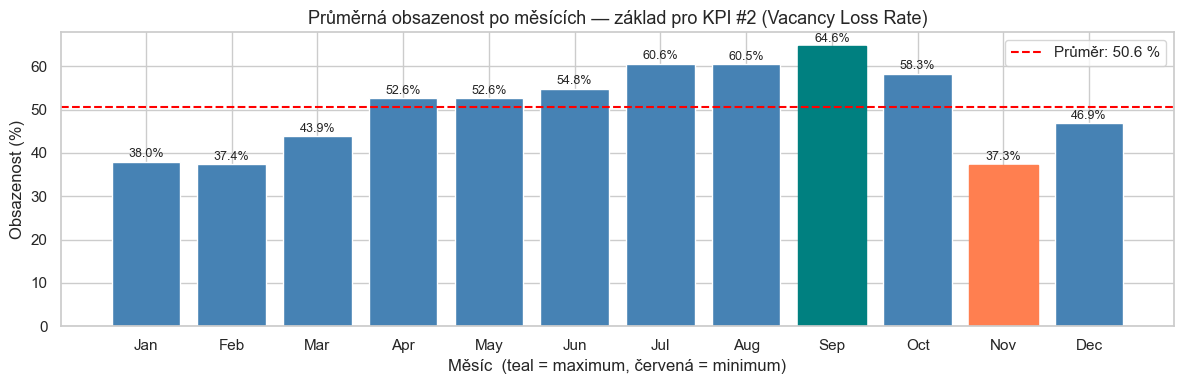

In [21]:
calendar['month']      = calendar['date'].dt.month
calendar['month_name'] = calendar['date'].dt.strftime('%b')
calendar['occupied']   = (calendar['available'] == 'f').astype(int)

monthly_occ = (
    calendar.groupby(['month', 'month_name'])['occupied']
    .mean().reset_index().sort_values('month')
)
monthly_occ['occupancy_pct'] = (monthly_occ['occupied'] * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(monthly_occ['month_name'], monthly_occ['occupancy_pct'],
              color='steelblue', edgecolor='white')

bars[monthly_occ['occupancy_pct'].idxmin()].set_color('coral')
bars[monthly_occ['occupancy_pct'].idxmax()].set_color('teal')

ax.axhline(monthly_occ['occupancy_pct'].mean(), color='red', linestyle='--',
           label=f'Průměr: {monthly_occ["occupancy_pct"].mean():.1f} %')
ax.set_title('Průměrná obsazenost po měsících — základ pro KPI #2 (Vacancy Loss Rate)')
ax.set_ylabel('Obsazenost (%)')
ax.set_xlabel('Měsíc  (teal = maximum, červená = minimum)')
ax.legend()

for bar, val in zip(bars, monthly_occ['occupancy_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

---
## 4. Metro stanice
### 4.1 Prvních a posledních 5 řádků

In [22]:
print('=== PRVNÍCH 5 ŘÁDKŮ ===')
print(metro.head().to_string())
print()
print('=== POSLEDNÍCH 5 ŘÁDKŮ ===')
print(metro.tail().to_string())

=== PRVNÍCH 5 ŘÁDKŮ ===
   station_id                name line  latitude  longitude
0           1     Nemocnice Motol    A  50.07559   14.34098
1           2             Petřiny    A  50.07999   14.35805
2           3  Nádraží Veleslavín    A  50.09068   14.36419
3           4          Bořislavka    A  50.09774   14.37786
4           5            Dejvická    A  50.10055   14.39168

=== POSLEDNÍCH 5 ŘÁDKŮ ===
    station_id                name line  latitude  longitude
56          57             Roztyly    C  50.02889   14.44407
57          58              Chodov    C  50.01866   14.47002
58          59              Opatov    C  50.01286   14.47932
59          60                Háje    C  50.00547   14.48882
60          61  Pražského povstání    C  50.06190   14.43198


In [23]:
print(f'Shape: {metro.shape[0]} řádků × {metro.shape[1]} sloupců')
print()
print('Datové typy:')
print(metro.dtypes.to_string())
print()
print('Chybějící hodnoty:')
print(metro.isnull().sum().to_string())
print()
print(f'Duplikáty: {metro.duplicated().sum()}')
print()
print('Počet stanic podle linky:')
print(metro.groupby('line')['name'].count().to_string())

Shape: 61 řádků × 5 sloupců

Datové typy:
station_id      int64
name              str
line              str
latitude      float64
longitude     float64

Chybějící hodnoty:
station_id    0
name          0
line          0
latitude      0
longitude     0

Duplikáty: 0

Počet stanic podle linky:
line
A    17
B    24
C    20


---
## 5. Geografická mapa — listings + metro

In [24]:
m = folium.Map(location=[50.075, 14.44], zoom_start=12, tiles='CartoDB positron')

sample = listings[['latitude', 'longitude', 'price_czk', 'room_type']].dropna().sample(1000, random_state=42)

for _, row in sample.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2, color='steelblue', fill=True, fill_opacity=0.5,
        popup=f"{row['room_type']}: {row['price_czk']:,.0f} CZK"
    ).add_to(m)

line_colors = {'A': 'green', 'B': 'goldenrod', 'C': 'red'}
for _, row in metro.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=7, color=line_colors.get(row['line'], 'gray'),
        fill=True, fill_opacity=0.9,
        popup=f"Metro {row['line']}: {row['name']}"
    ).add_to(m)

legend_html = '''
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
     background:white;padding:10px;border-radius:8px;
     border:1px solid #ccc;font-size:13px;">
  <b>Legenda</b><br>
  <span style="color:steelblue">●</span> Airbnb nabídka (vzorek 1 000)<br>
  <span style="color:green">●</span> Metro linka A<br>
  <span style="color:goldenrod">●</span> Metro linka B<br>
  <span style="color:red">●</span> Metro linka C
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))
m.save('../docs/map_listings_metro.html')
print('Mapa uložena → docs/map_listings_metro.html')
m

Mapa uložena → docs/map_listings_metro.html


---
## 6. Shrnutí zjištění a plán pro Data Preparation

- `calendar.adjusted_price`: 100 % NaN → nelze použít (stejně jako `calendar.price`)
- `calendar`: existují bloky `available=f` až 366 dní — pravděpodobně blokované 
  termíny nebo dlouhodobé pronájmy. V Data Preparation omezujeme délku pobytu 
  na max 30 dní (krátkodobý pronájem).
- Objekty s cenou > 99. percentilu (~21 823 CZK) a `Entire home/apt` < 400 CZK 
  považujeme za chybné záznamy nebo blokační ceny → nahrazujeme NaN a imputujeme.
- `price_czk` slabě koreluje s `accommodates` (r=0.09) → velké byty nejsou 
  nutně dražší → zajímavé pro KPI #3.

### Přehled datasetů

| Dataset | Řádků | Sloupců | Duplicity | Klíčový problém |
|---------|------:|-------:|----------:|----------------|
| listings | 10 834 | 79 | 0 | `price` 12 % NaN; formát `$2,272.00` |
| calendar | 3 954 411 | 7 | 0 | `price` 100 % NaN — nelze použít |
| metro_stations | 61 | 5 | 0 | Čistá data, žádné problémy |

### Identifikované problémy → akce v 02_data_preparation

| # | Problém | Sloupec | Navrhovaná akce |
|---|---------|---------|----------------|
| 1 | Formát ceny jako string | `price` | Odstranit `$` a `,`, převést na float |
| 2 | Chybějící ceny (12 %) | `price` | Imputace mediánem dle `neighbourhood_cleansed` + `room_type` |
| 3 | Sloupce s > 50 % NaN | více | Odstranit nepotřebné sloupce |
| 4 | `price` v calendar 100 % NaN | `calendar.price` | Calendar pouze pro dostupnost (available t/f) |
| 5 | Outliers v `price_czk` | `price_czk` | Zachovat; při analýze použít percentilové ořezání |
| 6 | Syntetická data chybí | — | Vygenerovat `bookings.csv` a `expenses.csv` |
| 7 | Vzdálenost od metra chybí | — | Vypočítat Haversine vzdálenost v notebook 02 |

### Vhodnost dat pro KPI

| KPI | Potřebná pole | Dostupnost | Poznámka |
|-----|--------------|:----------:|---------|
| #1 RevPAR × metro | `estimated_revenue_l365d`, souřadnice | ✅ | Vzdálenost od metra nutno dopočítat |
| #2 Vacancy Loss Rate | `calendar.available`, `date` | ✅ | Ceny z calendar nelze použít |
| #3 Capacity Utilization | `accommodates`, `estimated_revenue_l365d` | ✅ | Počet hostů generovat synteticky |

**Závěr:** Data jsou vhodná pro analýzu. Pokračujeme v **02_data_preparation.ipynb**.